# Exp 2 — ORS and $R_{\rm eff}$: Expressivity and Task Performance

This notebook benchmarks two complementary circuit diagnostics against task performance across circuit families.

| Experiment | Task | Qubits | Circuit sweep |
|---|---|---|---|
| 1 | QELM Fourier regression | n = 6 | G1/G2/G3 depth, D2_random degree |
| 2 | NARMA time series | n = 4 (3 memory + 1 encoding) | G1/G2/G3 depth, D2 family degree |

**ORS gap** $\Lambda - \Lambda_{\rm Haar}$: intrinsic expressivity, task-independent.  
**$R_{\rm eff}$**: effective rank of the feature matrix — how many independent directions the circuit exposes to the linear readout.

## ORS and $R_{\rm eff}$: Complementary Diagnostics

**Order-Statistics Score (ORS, $\Lambda$)** measures how close the output probability distribution is to the Haar (maximally random) distribution, using only the top-$K$ sorted probabilities. It is *intrinsic*: it depends only on the circuit, not on any task.  
The *ORS gap* $\Lambda - \Lambda_{\rm Haar}$ is negative when the circuit is less expressive than Haar; zero at Haar.

**Effective Rank ($R_{\rm eff}$)** measures the number of independent features the circuit exposes to the linear readout:
$$R_{\rm eff} = \frac{\bigl(\sum_i \sigma_i\bigr)^2}{\sum_i \sigma_i^2}$$
where $\sigma_i$ are the singular values of the centred feature matrix. It captures *task-conditioned* expressivity: the same circuit may have high ORS but a low-rank feature matrix for a particular encoding.

**Together:** high ORS + high $R_{\rm eff}$ → the circuit is both intrinsically complex and exposes many useful directions. Low ORS → fundamental expressivity bottleneck. Low $R_{\rm eff}$ with high ORS → encoding mismatch or feature collapse.

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullLocator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from tqdm import tqdm
from qiskit.quantum_info import SparsePauliOp

from metrics import lorentz_curves, order_statistics_score, lambda_haar_largeD
from QELM import QuantumCircQiskit
# ── Import run_qelm_experiment from shared module ──────────────────────────────
import sys as _sys
_fourier_dir = os.path.join('experiments', 'QELM', 'Fourier')
if _fourier_dir not in _sys.path:
    _sys.path.append(_fourier_dir)   # append so root Expressivity/QELM.py takes precedence
from qelm_utils import run_qelm_experiment

In [3]:
# ── Style constants ────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'Haar': '#000000', 'G1': 'royalblue', 'G2': 'mediumseagreen', 'G3': 'crimson',
    'D2_random': '#9467bd', 'D2_random_XZ': '#e377c2', 'D2_random_XZY': 'tab:orange',
}
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}
G_FAMILIES  = ['G1', 'G2', 'G3']
D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']


# ── Effective rank ─────────────────────────────────────────────────────────────
def effective_rank(F, eps=1e-12):
    """Participation ratio of singular values of the centred feature matrix."""
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd as sp_svd
        sv = sp_svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return float(sv.sum()**2 / (sv**2).sum())


def reff_from_var(var_x):
    """Approximate R_eff from per-feature standard deviations (diagonal covariance approximation)."""
    v = np.asarray(var_x, dtype=float).ravel()
    v = v[v > 1e-12]
    if len(v) == 0:
        return 0.0
    return float(v.sum()**2 / (v**2).sum())


# ── Random Pauli observables ───────────────────────────────────────────────────
def random_pauli_observables(n_obs, n_qubits, seed=42):
    rng = np.random.default_rng(seed)
    paulis = np.array(['I', 'X', 'Y', 'Z'])
    return [SparsePauliOp(''.join(rng.choice(paulis, size=n_qubits)))
            for _ in range(n_obs)]


# ── Fourier target function ────────────────────────────────────────────────────
def generate_target(x, n_a=6, seed=0):
    rng = np.random.default_rng(seed)
    K = (3**n_a - 1) // 2
    a = rng.uniform(-1, 1, size=K + 1)
    b = rng.uniform(-1, 1, size=K + 1)
    y = np.zeros_like(x)
    for k in range(K + 1):
        y += a[k] * np.cos(k * x) + b[k] * np.sin(k * x)
    return y


# ── ORS loading from noisy_basis files ────────────────────────────────────────
NOISY_BASIS_DIR = os.path.join('results', 'ors', 'noisy_basis')
B = 5  # number of Pauli bases used for mean / std

def load_ors_mb(fam, val, kind, n, f, K):
    """Load ORS gap (mean, std) from a noisy_basis file. Returns (NaN, NaN) if missing."""
    ftag = f'{f:.2f}'.replace('.', 'p')
    suffix = f'_ng{val}' if kind == 'ng' else f'_deg{val}_L1'
    path = os.path.join(NOISY_BASIS_DIR,
                        f'{fam}{suffix}_100runs_seed1234_basis4321_noise_multibasis.npz')
    if not os.path.exists(path):
        print('Path does not exist', path)
        return np.nan, np.nan
    d = np.load(path)
    key = f'gap_n{n}_K{K}_f{ftag}'
    if key not in d.files:
        print('Key not found: ', key, ' in file: ', path)
        return np.nan, np.nan
    gap = d[key][:B]
    return float(gap.mean()), float(gap.std()/B)

---
## Experiment 1 — QELM Fourier Regression (n = 6)

### Task

We fit a random Fourier series with $J_F = (3^{n_a} - 1)/2$ frequency components using a fixed quantum circuit as feature map and a linear readout:

$$y(x) = \sum_{j=0}^{J_F} \bigl[ a_j \cos(jx) + b_j \sin(jx) \bigr], \quad x \in [0, 2\pi)$$

Coefficients $a_j, b_j \sim \mathcal{U}(-1, 1)$ are fixed once (seed 0).

### Encoding

Each qubit is independently encoded as

$$|\psi_q(x)\rangle = R_z(-3^q\, x)\, H\, |0\rangle, \quad q = 0, \dots, n_a - 1$$

This *exponential* encoding generates Fourier components at frequencies up to $3^{n_a - 1}$, matching the target bandwidth exactly when $n_a = n$.

### Protocol

1. Draw $n_s = 100$ random reservoir circuits (fixed weights, different seeds)
2. Compute feature matrix $F \in \mathbb{R}^{N_{\rm train} \times n_{\rm obs}}$ using $n_{\rm obs}$ random Pauli observables
3. Fit $\hat{y} = F w$ with ordinary least squares
4. Report MSE on the held-out test set

Pre-computed results are loaded from `results/qelm/sine/`. ORS gap for D2 families uses `results/ors/noisy_basis/` at fidelity $f = 1$.

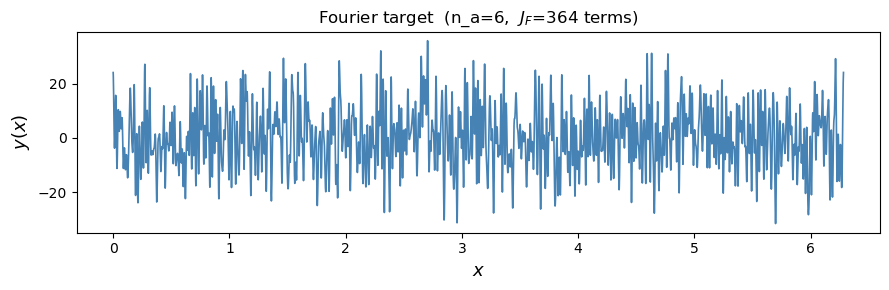

Test MSE For Haar reservoir:  3.1851707926782184e-25


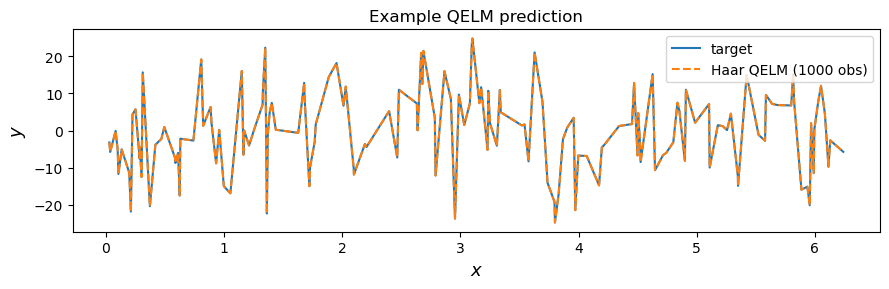

In [4]:
# ── Shared QELM data ───────────────────────────────────────────────────────────
N_QUBITS_QELM = 6
N_A = 6          # Fourier parameter (matches N_QUBITS_QELM)
N_SAMPLES = 5000
K_QELM = 4      # ORS top-K

x_all = np.linspace(0, 2 * np.pi, N_SAMPLES, endpoint=False)
y_all = generate_target(x_all, n_a=N_A, seed=0)
idx_tr, idx_te = train_test_split(np.arange(N_SAMPLES), test_size=0.3, random_state=42)
x_train, x_test = x_all[idx_tr], x_all[idx_te]
y_train, y_test = y_all[idx_tr], y_all[idx_te]

# Target function
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x_all, y_all, lw=1.2, color='steelblue')
ax.set_xlabel(r'$x$', fontsize=13)
ax.set_ylabel(r'$y(x)$', fontsize=13)
ax.set_title(f'Fourier target  (n_a={N_A},  $J_F$={(3**N_A - 1)//2} terms)')
fig.tight_layout(); plt.show()

# Example QELM prediction (Haar circuit, 1000 observables)
_obs_ex = random_pauli_observables(1000, N_QUBITS_QELM, seed=42)
np.random.seed(0)
qrc_ex = QuantumCircQiskit('Haar', nqbits=N_QUBITS_QELM, 
                            observables_type=_obs_ex, encoding='exponential',theta_scale=1.0,
                            k_exp=N_QUBITS_QELM, statevector=True)
Ftr_ex = qrc_ex.feature_matrix(x_train)
Fte_ex = qrc_ex.feature_matrix(x_test)
y_hat_ex = LinearRegression().fit(Ftr_ex, y_train).predict(Fte_ex)
mse = np.mean((y_hat_ex - y_test)**2)
print('Test MSE For Haar reservoir: ', mse)

idx_s = np.argsort(x_test[:150])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x_test[:150][idx_s], y_test[:150][idx_s], lw=1.5, label='target')
ax.plot(x_test[:150][idx_s], y_hat_ex[:150][idx_s], '--', lw=1.5, label='Haar QELM (1000 obs)')
ax.set_xlabel(r'$x$', fontsize=13); ax.set_ylabel(r'$y$', fontsize=13)
ax.set_title('Example QELM prediction'); ax.legend()
fig.tight_layout(); plt.show()

In [11]:
# ── Load pre-computed QELM results ────────────────────────────────────────────
SINE_DIR = os.path.join('results', 'qelm', 'sine')
F_ORS = 1.0

QELM_G_FAMILIES  = ['G1', 'G2', 'G3']
QELM_D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']
G_DEPTHS   = [10, 20, 50, 100, 200, 1000]
D2_DEGREES = [1, 2, 4, 6, 8, 10]

HAAR_ORS_QELM = lambda_haar_largeD(2**N_QUBITS_QELM, K_QELM)


def _qelm_path(fam, val, kind):
    if fam == 'Haar':
        return os.path.join(SINE_DIR, 'Haar_6q_100runs.npz')
    suffix = f'ng{val}' if kind == 'ng' else f'deg{val}'
    return os.path.join(SINE_DIR, f'{fam}_{suffix}_6q_100runs.npz')


def _qelm_stats(fam_name, xs, kind):
    """Load QELM metrics for one family across hyperparameter values."""
    out = {'xs': [], 'ors_gap': [], 'reff': [], 'mse': []}
    for val in xs:
        path = _qelm_path(fam_name, val, kind)
        if not os.path.exists(path):
            print('Path does not exist, ', path)
            continue
        d    = np.load(path)
        mse  = d['mse'][:, -1]     # (ns,) at max n_obs
        reff = d['reff'][:, -1]    # (ns,) at max n_obs

        # ORS gap from noisy_basis only (NaN → point omitted in plot)
        ors_m, ors_s = load_ors_mb(fam_name, val, kind, N_QUBITS_QELM, F_ORS, K_QELM)

        out['xs'].append(val)
        out['ors_gap'].append((ors_m, ors_s))
        out['reff'].append(reff.mean())
        out['mse'].append((mse.mean(), mse.std() / np.sqrt(len(mse))))
    out['xs'] = np.array(out['xs'])
    return out


data_g_qelm  = {fam: _qelm_stats(fam, G_DEPTHS,   'ng')  for fam in QELM_G_FAMILIES}
data_d2_qelm = {fam: _qelm_stats(fam, D2_DEGREES, 'deg') for fam in QELM_D2_FAMILIES}

# Haar reference
_haar_path = _qelm_path('Haar', None, None)
if os.path.exists(_haar_path):
    _d_haar = np.load(_haar_path)
    haar_refs_qelm = {
        'ors':     0.0,
        'ors_gap': 0.0,
        'reff':    float(_d_haar['reff'][:, -1].mean()),
        'mse':     float(_d_haar['mse'][:, -1].mean()),
    }
else:
    haar_refs_qelm = {'ors': 0.0, 'ors_gap': 0.0, 'reff': np.nan, 'mse': np.nan}
print('Haar refs:', {k: f'{v:.3g}' for k, v in haar_refs_qelm.items() if isinstance(v, float)})

Haar refs: {'ors': '0', 'ors_gap': '0', 'reff': 'nan', 'mse': 'nan'}


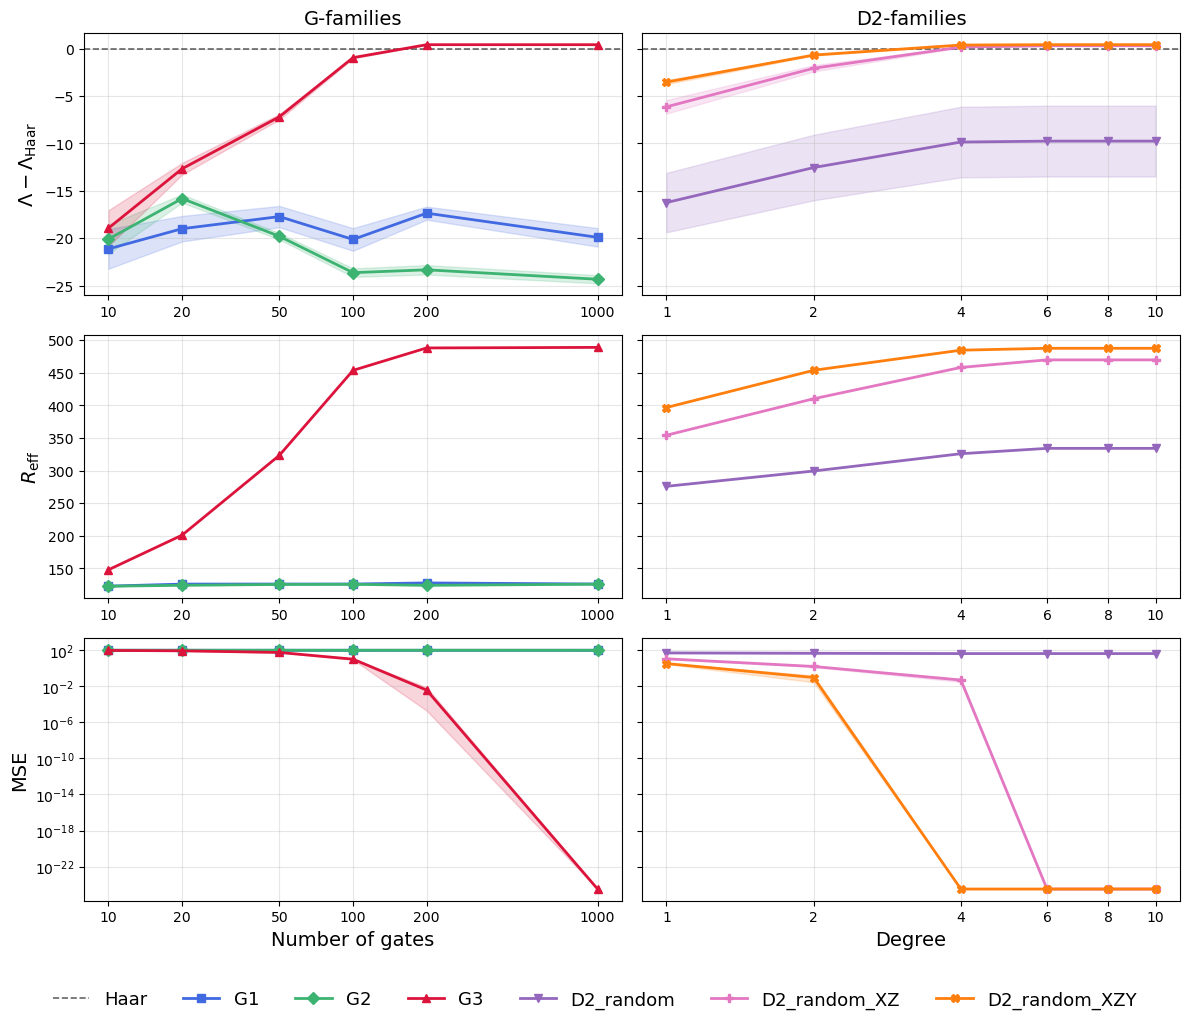

In [13]:
# ── 3×2 diagnostic figure ─────────────────────────────────────────────────────
def plot_diagnostics(data_g, data_d2, haar_refs, g_xlabel, d_xlabel,
                     g_families=None, d_families=None, save_path=None):
    """3×2 grid: (ORS gap, R_eff, MSE) × (G-families | D2-families)."""
    if g_families is None:
        g_families = [f for f in G_FAMILIES if f in data_g]
    if d_families is None:
        d_families = [f for f in D2_FAMILIES if f in data_d2]

    metrics = [
        ('ors_gap', r'$\Lambda - \Lambda_{\rm Haar}$'),
        ('reff',    r'$R_{\rm eff}$'),
        ('mse',     'MSE'),
    ]
    col_specs = [
        ('G-families',  g_families, data_g,  g_xlabel),
        ('D2-families', d_families, data_d2, d_xlabel),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey='row')

    for row, (key, ylabel) in enumerate(metrics):
        href = haar_refs.get(key)
        for col, (title, fams, data, xlabel) in enumerate(col_specs):
            ax = axes[row, col]
            if href is not None and np.isfinite(href):
                ax.axhline(href, color=FAMILY_COLORS['Haar'], ls='--', lw=1.2, alpha=0.6,
                           label='Haar' if row == 0 else None)
            xs_last = np.array([])
            for fam in fams:
                d = data.get(fam, {}); xs = d.get('xs', np.array([]))
                if len(xs) == 0:
                    continue
                xs_last = xs
                c, m = FAMILY_COLORS.get(fam, '#888'), FAMILY_MARKERS.get(fam, 'o')
                if key == 'reff':
                    ys = np.array(d['reff'])
                    ax.plot(xs, ys, marker=m, color=c, lw=2,
                            label=fam if row == 0 else None)
                elif key == 'ors_gap':
                    vals = d.get(key, [])
                    ms = np.array([v[0] for v in vals]) - haar_refs.get('ors')
                    ss = np.array([v[1] for v in vals])
                    ok = np.isfinite(ms)
                    ax.plot(xs[ok], ms[ok], marker=m, color=c, lw=2,
                            label=fam if row == 0 else None)
                    ax.fill_between(xs[ok], ms[ok] - ss[ok], ms[ok] + ss[ok],
                                    color=c, alpha=0.18)
                else:
                    vals = d.get(key, [])
                    ms = np.array([v[0] for v in vals])
                    ss = np.array([v[1] for v in vals])
                    ok = np.isfinite(ms)
                    ax.plot(xs[ok], ms[ok], marker=m, color=c, lw=2,
                            label=fam if row == 0 else None)
                    ax.fill_between(xs[ok], ms[ok] - ss[ok], ms[ok] + ss[ok],
                                    color=c, alpha=0.18)
            ax.set_xscale('log')
            if len(xs_last) > 0:
                ax.set_xticks(xs_last)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())
            if key == 'mse':
                ax.set_yscale('log')
            ax.grid(True, which='both', alpha=0.3)
            if row == 0: ax.set_title(title, fontsize=14)
            if row == 2: ax.set_xlabel(xlabel, fontsize=14)
            if col == 0: ax.set_ylabel(ylabel, fontsize=14)

    seen = {}
    for ax in axes[0]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            seen.setdefault(l, h)
    fig.legend(seen.values(), seen.keys(), loc='upper center',
               bbox_to_anchor=(0.5, -0.01), ncol=len(seen), fontsize=13, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


plot_diagnostics(
    data_g_qelm, data_d2_qelm, haar_refs_qelm,
    g_xlabel='Number of gates', d_xlabel='Degree',
    d_families=QELM_D2_FAMILIES,
    save_path=os.path.join('figures', 'fig2_qelm.png'),
)

---
## Experiment 2 — NARMA Time Series with Fourier Encoding (n = 3)

### Task

NARMA-10 is a nonlinear autoregressive benchmark with long-range temporal dependencies:

$$u(t+1) = \alpha\,u(t) + \beta\,u(t)\sum_{j=0}^{m-1} u(t-j) + \gamma\,u(t-m+1)\,u(t) + \delta$$

with $\alpha=0.3$, $\beta=0.05$, $\gamma=1.5$, $\delta=0.1$, order $m=10$.  
Input $s(t) \sim \mathcal{U}(0, 0.5)$, initialised at zero.

### Encoding

The Fourier injection encodes the scalar input $s(t)$ into qubit $k$ as:

$$\theta_k(t) = 3^k \cdot s(t), \quad k = 0, \dots, n-1$$

This exponential rescaling creates a rich Fourier spectrum with bandwidth $\sim 3^{n-1}$.

### Protocol

Pre-computed results are loaded from `results/time_series/NARMA/`. $R_{\rm eff}$ is computed from the stored training feature matrix `X_train_e` and saved back to each file on the first run (one-time cell). ORS gap uses the `ors` values stored in each file — the noisy_basis files do not cover $n = 3$.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def generate_narma_fourier_task(
    T=2000, n_train=1400, narma_order=5,
    n_a=6, seed=0, normalize=True, use_g = True,
):
    """
    NARMA-n task with Fourier-rich external input.
    
    The input to the QRC is u_t ∈ [0, 2π] (uniform random).
    The driver s_t = g(u_t) where g has frequencies matching the
    exponential encoding's budget for n_a qubits.
    The target y_{t+1} follows NARMA dynamics in s_t and past y.
    
    Parameters
    ----------
    T : int
        Total length of the time series.
    n_train : int
        Length of training set.
    narma_order : int
        NARMA memory depth. 5 is standard; 10 tests longer memory.
    n_a : int
        Encoding qubit count — determines g's frequency content.
    """
    rng = np.random.default_rng(seed)
    K = (3 ** n_a - 1) // 2  # 364 for n_a=6
    
    # Random Fourier coefficients for g
    a = rng.uniform(-1, 1, size=K + 1)
    b = rng.uniform(-1, 1, size=K + 1)
    
    def g(u):
        """Fourier-rich driver function: g: [0, 2π] → R, with frequencies up to K."""
        u = np.atleast_1d(u)
        out = np.zeros_like(u, dtype=float)
        for k in range(K + 1):
            out += a[k] * np.cos(k * u) + b[k] * np.sin(k * u)
        return out
    
    
    # Normalize g to [0, 0.5] (NARMA expects s_t ∈ [0, 0.5])
    u_probe = np.linspace(0, 2 * np.pi, 5000)
    g_vals = g(u_probe) if use_g else u_probe
    g_min, g_max = g_vals.min(), g_vals.max()
    
    def g_normalized(u):
        if use_g:
            return 0.5 * (g(u) - g_min) / (g_max - g_min)
        return 0.5 * (u - g_min) / (g_max - g_min)
    
    # Generate input sequence u_t and driver s_t
    u = rng.uniform(0, 2 * np.pi, size=T)
    s = g_normalized(u)
    
    # Run NARMA dynamics: need narma_order burn-in steps
    y = np.zeros(T)
    n = narma_order
    for t in range(n - 1, T - 1):
        y[t + 1] = (0.3 * y[t] 
                    + 0.05 * y[t] * np.mean(y[t - n + 1:t + 1])
                    + 1.5 * s[t - n + 1] * s[t] 
                    + 0.1)
    
    # Drop burn-in
    u = u[n:]
    y = y[n:]
    T_eff = len(y)
    assert n_train < T_eff
    
    # QRC input: u_t (the reservoir sees u_t and must predict y_{t+1})
    # Target: y itself
    u = u.reshape(-1, 1)
    y = y.reshape(-1, 1)
    u_train, u_test = u[:n_train], u[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]
    
    scaler = None
    if normalize:
        # Scale the INPUT u to [0, 1] so the QRC encoding sees a standard range
        u_scaler = MinMaxScaler(feature_range=(0, 1))
        u_train = u_scaler.fit_transform(u_train)
        u_test = u_scaler.transform(u_test)
        # Scale the target separately
        y_scaler = MinMaxScaler(feature_range=(0, 1))
        y_train = y_scaler.fit_transform(y_train)
        y_test = y_scaler.transform(y_test)
        scaler = (u_scaler, y_scaler)
    
    return {
        'u_train': u_train, 'u_test': u_test,   # QRC inputs
        'y_train': y_train, 'y_test': y_test,   # targets
        'g': g_normalized,
        'K': K,
        'narma_order': narma_order,
        'scaler': scaler,
    }


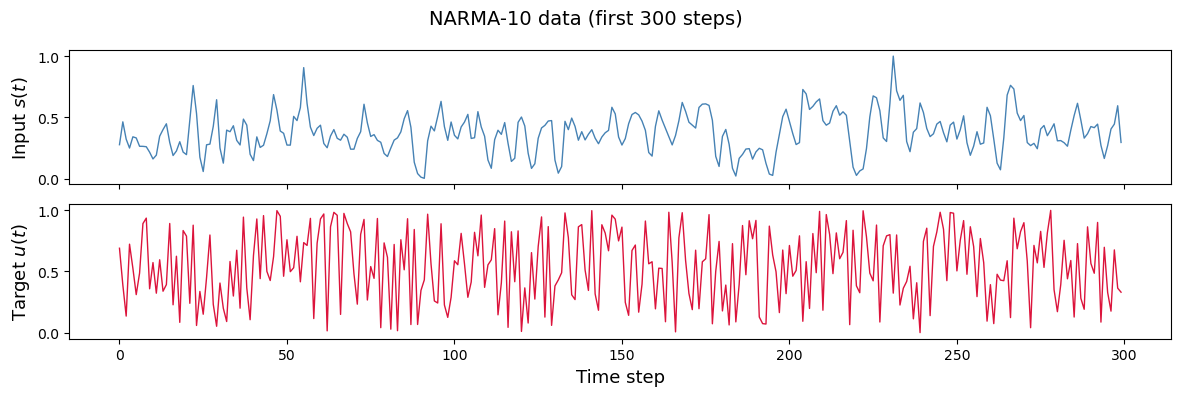

In [51]:
data = generate_narma_fourier_task(T=5000, n_train=4000, narma_order=2, n_a=3)
u_train, y_train = data['u_train'], data['y_train']
u_test, y_test = data['u_test'], data['y_test']
t_train = np.arange(len(y_train))
t_test = np.arange(len(y_train), len(y_train) + len(y_test))

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(y_train[:300], lw=1.0, color='steelblue')
axes[0].set_ylabel(r'Input $s(t)$', fontsize=13)
axes[1].plot(u_train[:300], lw=1.0, color='crimson')
axes[1].set_ylabel(r'Target $u(t)$', fontsize=13)
axes[1].set_xlabel('Time step', fontsize=13)
fig.suptitle('NARMA-10 data (first 300 steps)', fontsize=14)
fig.tight_layout(); plt.show()

In [48]:
from QRC import QuantumRC_Circuit

def run_narma_experiment(
    gates_name,
    data,
    n_obs_list,
    ns=10,
    nqbits=3,
    k_exp=3,
    theta_scale=2*np.pi,
    n_measure=6,
    alpha=1e-10,
    # Mode controls
    input_mode='exogenous',      # 'exogenous' | 'autoregressive' | 'hybrid'
    feedback='teacher',          # 'teacher' | 'closed_loop'
    dim_s=1,
    dim_y=1,
    # Complexity-metric config
    nshots_ors=2000,
    K_ors=None,
    t_dismiss=0,                  # washout steps to exclude from var_x
    # Training options
    retrain_on_test=False,
    verbose=False,
    **circuit_kwargs,
):
    """
    NARMA analogue of run_sine_experiment for QuantumRC_Circuit.

    Single-pass (fast) when the reservoir trajectory is independent of the
    readout (exogenous OR teacher-forced); rebuilds per n_obs otherwise.
    """
    s_train = data.get('u_train')
    s_test  = data.get('u_test')
    y_train = data['y_train']
    y_test  = data['y_test']
    n_test = y_test.shape[0]
    max_n_obs = n_obs_list[-1]
    if K_ors is None:
        K_ors = 2**nqbits

    single_pass = (input_mode == 'exogenous') or (feedback == 'teacher')

    # ── Result containers ────────────────────────────────────────────────
    mse_p = np.zeros((ns, len(n_obs_list)))
    mse_e = np.zeros((ns, len(n_obs_list)))
    yp_all = np.zeros((ns, len(n_obs_list), n_test))
    ye_all = np.zeros((ns, len(n_obs_list), n_test))
    ors_list, delta_s_list = [], []
    var_x_p_list, var_x_e_list = [], []
    # Keep only the last run's feature matrices (for sanity checks/plotting)
    Xp_tr_last = Xp_te_last = Xe_tr_last = Xe_te_last = None

    def _make_qrc(encoding, seed, n_obs=None):
        np.random.seed(seed)
        qrc = QuantumRC_Circuit(
            nqbits=nqbits, gates_set=gates_name, encoding=encoding,
            k_exp=k_exp, theta_scale=theta_scale, n_measure=n_measure,
            observables_type=[1, 2, 3], alpha=alpha,
            input_mode=input_mode, feedback=feedback,
            dim_s=dim_s, dim_y=dim_y,
            **circuit_kwargs,
        )
        trunc_to = max_n_obs if single_pass else n_obs
        qrc.observables = qrc.observables[:trunc_to]
        qrc.obs_array = np.array([o.to_matrix() for o in qrc.observables])
        return qrc

    def _call_train(qrc, cache=False):
        if input_mode == 'autoregressive':
            return qrc.train(y=y_train, cache_dm_traj=cache)
        return qrc.train(s=s_train, y=y_train, cache_dm_traj=cache)

    def _call_test(qrc, cache=False):
        kwargs = dict(retrain=retrain_on_test, cache_dm_traj=cache)
        if input_mode == 'autoregressive':
            return qrc.test(y=y_test, **kwargs)
        return qrc.test(s=s_test, y=y_test, **kwargs)

    def _project(dm_traj, obs):
        f = np.tensordot(obs, dm_traj, axes=[[2, 1], [1, 2]]).real
        return f.T[:-1]

    def _fit_and_predict(X_tr, y_tr, X_te, y_te, retrain):
        lm = Ridge(alpha=alpha).fit(X_tr, y_tr)
        preds, X_aug, y_aug = [], X_tr.copy(), y_tr.copy()
        for i in range(X_te.shape[0]):
            row = X_te[i:i+1]
            preds.append(lm.predict(row).ravel())
            if retrain:
                X_aug = np.vstack([X_aug, row])
                y_aug = np.vstack([y_aug, y_te[i].reshape(1, -1)])
                lm = Ridge(alpha=alpha).fit(X_aug, y_aug)
        return np.array(preds).ravel()

    desc = f"NARMA [{gates_name}] {input_mode}/{feedback}"
    for run in tqdm(range(ns), desc=desc):
        seed = run * 2

        if single_pass:
            qrc_p = _make_qrc('pauli', seed)
            qrc_e = _make_qrc('exponential', seed)

            _call_train(qrc_p, cache=True); dm_p_tr = qrc_p.dm_traj
            _call_test(qrc_p,  cache=True); dm_p_te = qrc_p.dm_traj
            _call_train(qrc_e, cache=True); dm_e_tr = qrc_e.dm_traj
            _call_test(qrc_e,  cache=True); dm_e_te = qrc_e.dm_traj

            full_obs = qrc_p.obs_array
            Xp_tr = _project(dm_p_tr, full_obs)
            Xp_te = _project(dm_p_te, full_obs)
            Xe_tr = _project(dm_e_tr, full_obs)
            Xe_te = _project(dm_e_te, full_obs)

            # Complexity metrics (reservoir-only; same for both encodings)
            _, sp, _ = lorentz_curves(
                qrc_p.get_reservoir, qrc_p.n_total, nshots_ors, 1, verbose=False)
            ors_list.append(
                order_statistics_score(sp, D=2**qrc_p.n_total, K=K_ors))

            # Input sensitivity per encoding: variance over time
            # (excluding washout transient if specified)
            var_x_p_list.append(np.std(Xp_tr[t_dismiss:], axis=0))
            var_x_e_list.append(np.std(Xe_tr[t_dismiss:], axis=0))

            # Sweep n_obs
            for i, n_obs in enumerate(n_obs_list):
                yp = _fit_and_predict(Xp_tr[:, :n_obs], y_train,
                                      Xp_te[:, :n_obs], y_test, retrain_on_test)
                ye = _fit_and_predict(Xe_tr[:, :n_obs], y_train,
                                      Xe_te[:, :n_obs], y_test, retrain_on_test)
                yp_all[run, i] = yp;  ye_all[run, i] = ye
                mse_p[run, i] = np.mean((yp - y_test.ravel())**2)
                mse_e[run, i] = np.mean((ye - y_test.ravel())**2)
                if verbose:
                    print(f"  run={run} n_obs={n_obs:3d}  "
                          f"pauli={mse_p[run,i]:.4e}  exp={mse_e[run,i]:.4e}")

            # Save last run's feature matrices for inspection
            Xp_tr_last, Xp_te_last = Xp_tr, Xp_te
            Xe_tr_last, Xe_te_last = Xe_tr, Xe_te

        else:
            # Closed-loop: rebuild per n_obs
            qrc_ref = _make_qrc('pauli', seed, n_obs=max_n_obs)
            _, sp, _ = lorentz_curves(
                qrc_ref.get_reservoir, qrc_ref.n_total, nshots_ors, 1, verbose=False)
            ors_list.append(
                order_statistics_score(sp, D=2**qrc_ref.n_total, K=K_ors))
            _call_train(qrc_ref)
            # In closed-loop we only have one trajectory available cheaply (Pauli ref)
            var_x_p_list.append(np.std(qrc_ref.X_train[t_dismiss:], axis=0))
            var_x_e_list.append(np.full_like(var_x_p_list[-1], np.nan))

            for i, n_obs in enumerate(n_obs_list):
                qrc_p = _make_qrc('pauli', seed, n_obs=n_obs)
                qrc_e = _make_qrc('exponential', seed, n_obs=n_obs)
                _call_train(qrc_p); yp = _call_test(qrc_p).ravel()
                _call_train(qrc_e); ye = _call_test(qrc_e).ravel()
                yp_all[run, i] = yp; ye_all[run, i] = ye
                mse_p[run, i] = np.mean((yp - y_test.ravel())**2)
                mse_e[run, i] = np.mean((ye - y_test.ravel())**2)
                if verbose:
                    print(f"  run={run} n_obs={n_obs:3d}  "
                          f"pauli={mse_p[run,i]:.4e}  exp={mse_e[run,i]:.4e}")

    # Stack var_x lists; rows of unequal length only happen if reservoirs differ,
    # which they don't here (same nqbits/n_measure across runs)
    return {
        'mse_p': mse_p, 'mse_e': mse_e,
        'y_pred_p': yp_all, 'y_pred_e': ye_all,
        'ors': np.array(ors_list),
        'delta_s': np.array(delta_s_list),
        'var_x_p': np.array(var_x_p_list),
        'var_x_e': np.array(var_x_e_list),
        'X_train_p': Xp_tr_last, 'X_test_p': Xp_te_last,
        'X_train_e': Xe_tr_last, 'X_test_e': Xe_te_last,
    }

In [22]:
# ── Load NARMA results ─────────────────────────────────────────────────────────
NARMA_DIR    = os.path.join('results', 'time_series', 'NARMA')
NQBITS_NARMA = 3
K_NARMA      = 4
N_ORS_NARMA  = 6   # noisy_basis covers n ∈ {6,8,10,12,16}; use n=6 for NARMA ORS
F_ORS_NARMA  = 1.0

NARMA_G_DEPTHS = [10, 20, 50, 100, 200, 1000]
NARMA_D2_DEGS  = [1, 2, 4, 6, 8, 10]


def _load_narma(path):
    d = np.load(path)
    res = {k: np.asarray(d[k]) for k in d.files}
    if 'reff_e' not in res and 'X_train_e' in res:
        res['reff_e'] = np.array([effective_rank(res['X_train_e'])])
    return res


def _narma_path(fam, kind, val):
    if kind == 'ng':
        return os.path.join(NARMA_DIR, f'{fam}_ng{int(val)}_{NQBITS_NARMA}q_100runs.npz')
    return os.path.join(NARMA_DIR, f'{fam}_deg{float(val)}_{NQBITS_NARMA}q_100runs.npz')


def _narma_stats(fam, xs, kind):
    out = {'xs': [], 'ors_gap': [], 'reff': [], 'mse': []}
    for val in xs:
        path = _narma_path(fam, kind, val)
        if not os.path.exists(path):
            continue
        d = _load_narma(path)
        mse      = d['mse_e'][:, -1]              # (ns,) at max n_obs
        reff_val = float(np.atleast_1d(d['reff_e']).mean())

        # ORS gap from noisy_basis at n=6 (same files as QELM; NaN → point skipped in plot)
        ors_m, ors_s = load_ors_mb(fam, val, kind, N_ORS_NARMA, F_ORS_NARMA, K_NARMA)

        out['xs'].append(val)
        out['ors_gap'].append((ors_m, ors_s))
        out['reff'].append(reff_val)
        out['mse'].append((mse.mean(), mse.std() / np.sqrt(len(mse))))

    out['xs'] = np.array(out['xs'])
    return out


data_g_narma  = {fam: _narma_stats(fam, NARMA_G_DEPTHS, 'ng')  for fam in G_FAMILIES}
data_d2_narma = {fam: _narma_stats(fam, NARMA_D2_DEGS,  'deg') for fam in D2_FAMILIES}

# Haar reference (ORS gap = 0 by definition)
_d_haar_n = _load_narma(os.path.join(NARMA_DIR, f'Haar_{NQBITS_NARMA}q_100runs.npz'))
haar_refs_narma = {
    'ors':  0.0,
    'ors_gap': 0.0,
    'reff': float(np.atleast_1d(_d_haar_n['reff_e']).mean()),
    'mse':  float(_d_haar_n['mse_e'][:, -1].mean()),
}
print('NARMA Haar refs:', {k: f'{v:.3g}' for k, v in haar_refs_narma.items()})

NARMA Haar refs: {'ors': '0', 'ors_gap': '0', 'reff': '142', 'mse': '0.00702'}


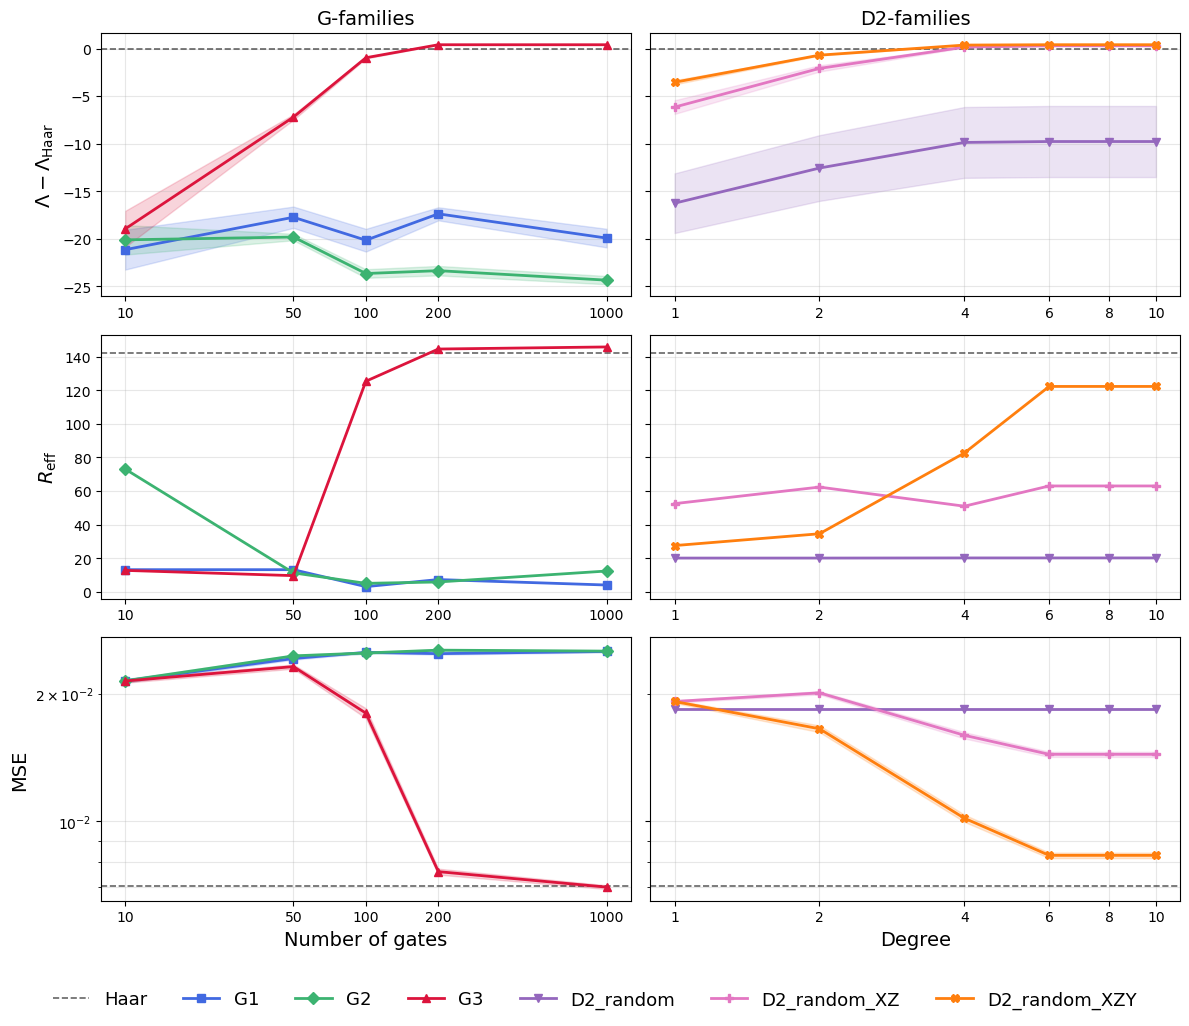

In [23]:
plot_diagnostics(
    data_g_narma, data_d2_narma, haar_refs_narma,
    g_xlabel='Number of gates', d_xlabel='Degree',
    save_path=os.path.join('figures', 'fig2_narma.png'),
)